#Part I - Ford GoBike Trip Data Exploration 
by Rakesh Ravula

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [6]:
df = pd.read_csv("201902-fordgobike-tripdata.csv")

In [7]:
df.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [9]:
df.shape

(183412, 16)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [11]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [12]:
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [13]:
df = df.dropna()

In [14]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [15]:
df['age'] = 2019 - df['member_birth_year']

In [16]:
df[['member_birth_year','age']].head()

,member_birth_year,age
0,1984.0,35.0
2,1972.0,47.0
3,1989.0,30.0
4,1974.0,45.0
5,1959.0,60.0


In [17]:
df = df[df['age'] < 90]

#Preliminary Wrangling

1.What is the structure of your dataset?

The dataset consists of 183,412 observations and 16 variables. The variables include both numerical and categorical data.

Main variables include:

duration_sec
start_time
end_time
start_station_name
end_station_name
bike_id
user_type
member_birth_year
member_gender
bike_share_for_all_trip

Some missing values exist in the demographic variables such as gender and birth year. These records will be removed during data cleaning. Date columns are converted into datetime format, and an additional age variable is created using the birth year.

2.What is/are the main feature(s) of interest in your dataset?

The primary feature of interest is trip duration (duration_sec) because it represents user riding behavior and overall service usage.

Other important features include:

User Type
Member Gender
Age
Bike Share for All Trip

These variables help explain differences in riding patterns among different user groups.

3.What features in the dataset do you think will help support your investigation into your feature(s) of interest?

The following features are expected to support the investigation:

User Type (Subscriber or Customer)
Member Gender
Member Birth Year (Age)
Bike Share for All Trip
Start Time
End Time

These variables provide demographic and behavioral information that may influence trip duration.

# Univariate Exploration

1.How is trip duration distributed??

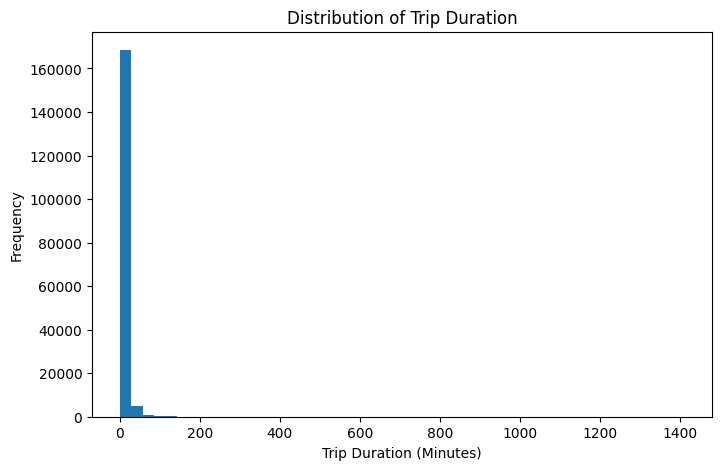

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['duration_sec']/60,
         bins=50)

plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Duration")

plt.show()

Observation

The trip duration distribution is highly right-skewed. Most trips last between 5 and 15 minutes, while only a small number of trips have very long durations. Long-duration trips appear to be outliers.

2.Which user type is most common?

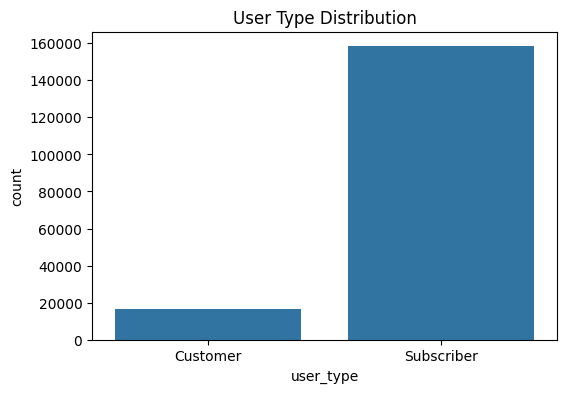

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x='user_type')

plt.title("User Type Distribution")

plt.show()

Observation

Subscribers represent the majority of users in the dataset, indicating that regular members use the bike-sharing service more frequently than casual customers.

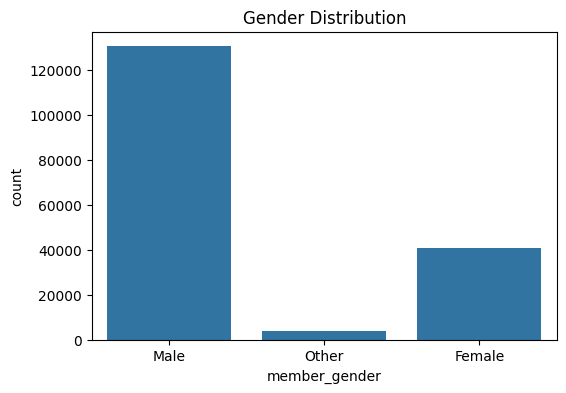

In [20]:
#What is the gender distribution of riders?

plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x='member_gender')

plt.title("Gender Distribution")

plt.show()

Observation

Male riders account for the largest proportion of users, followed by female riders. Only a small percentage of riders identify as "Other."

#Univariate Discussion

The trip duration variable shows a positively skewed distribution with several extreme values. To improve visualization and analysis, extremely large values may be excluded or logarithmic scaling may be applied.

During data cleaning:

Missing values were removed.
Date columns were converted into datetime format.
An age variable was created.
Unrealistic ages greater than 90 years were removed to reduce the effect of outliers.

These preprocessing steps improved data quality for further analysis.

# Bivariate Exploration

1.Does age influence trip duration?

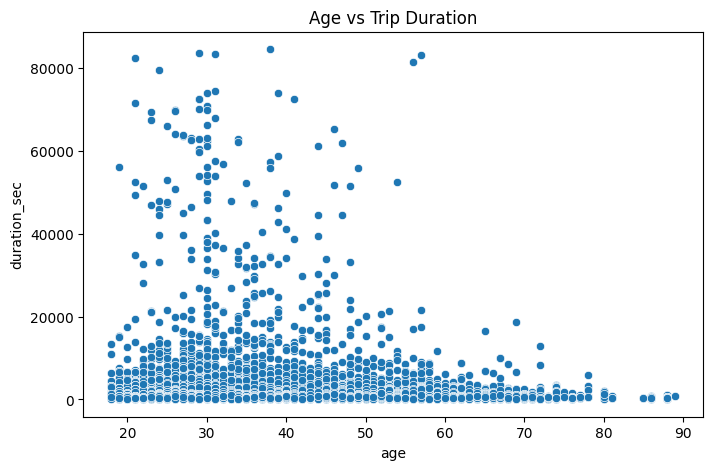

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='age',
    y='duration_sec'
)

plt.title("Age vs Trip Duration")

plt.show()

Observation

The scatter plot indicates no strong linear relationship between age and trip duration. Most users, regardless of age, take relatively short trips.

2.Does user type affect trip duration?

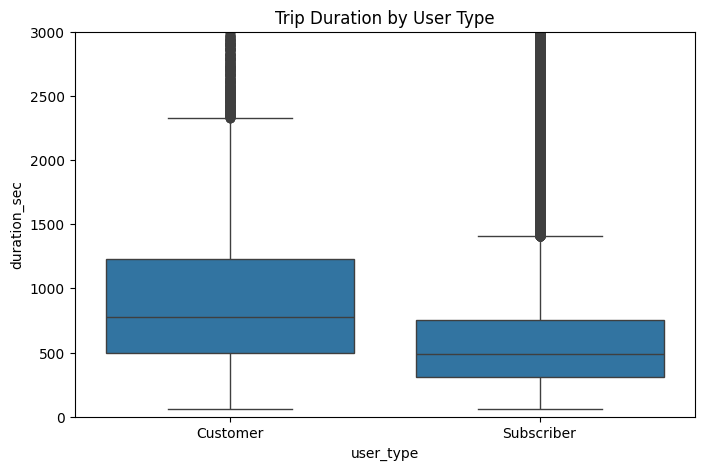

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='user_type',
    y='duration_sec'
)

plt.ylim(0,3000)

plt.title("Trip Duration by User Type")

plt.show()

Observation

Customers generally have longer trip durations compared to subscribers. Subscribers tend to make shorter, more consistent trips, suggesting that they primarily use the bikes for commuting.

3.Is there a relationship between gender and user type?

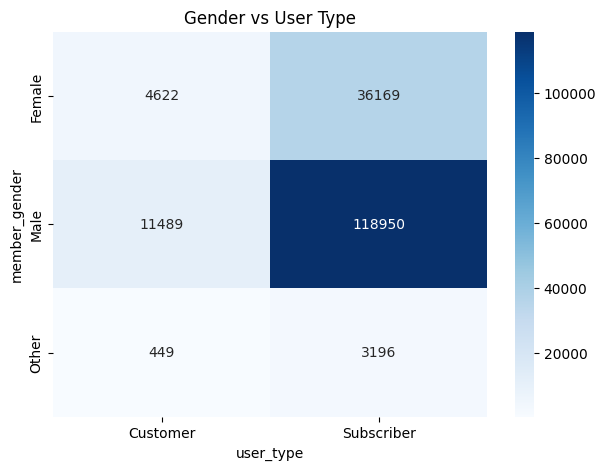

In [23]:
plt.figure(figsize=(7,5))

sns.heatmap(
    pd.crosstab(df['member_gender'],
                df['user_type']),
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Gender vs User Type")

plt.show()

Observation

Male subscribers make up the largest user group. Female subscribers are the second-largest group, while customers represent a much smaller proportion across all genders

# Bivariate Discussion

Trip duration varies noticeably by user type. Customers typically spend more time riding than subscribers. Age shows only a weak relationship with trip duration, while gender mainly influences the overall number of trips rather than trip length.

# Multivariate Exploration


1.How do gender and user type together affect trip duration?


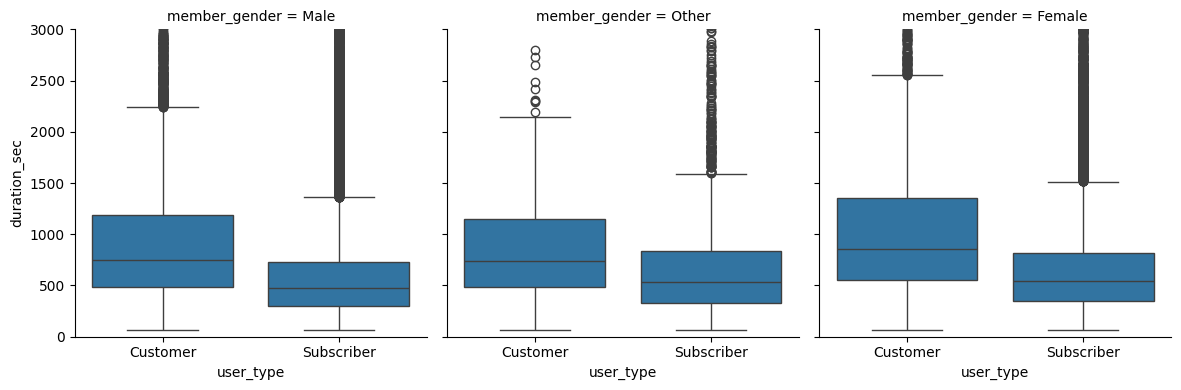

In [24]:
g = sns.FacetGrid(
    df,
    col="member_gender",
    height=4
)

g.map_dataframe(
    sns.boxplot,
    x="user_type",
    y="duration_sec"
)

g.set(ylim=(0,3000))

plt.show()


Observation

Across all genders, subscribers consistently have shorter trip durations than customers. This pattern remains similar regardless of gender.

2.How do age, trip duration, and user type interact?

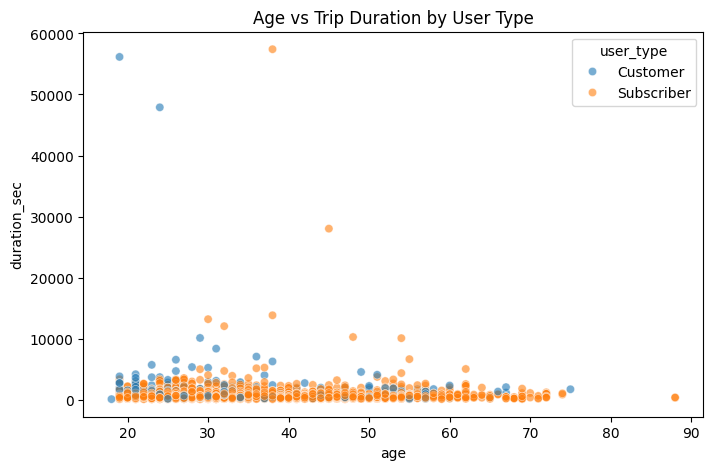

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='age',
    y='duration_sec',
    hue='user_type',
    alpha=0.6
)

plt.title("Age vs Trip Duration by User Type")

plt.show()

Observation

Subscribers are concentrated around shorter trip durations, while customers display greater variability and generally longer rides. Age has little influence on this overall pattern.

# Multivariate Discussion

The multivariate analysis reinforces earlier findings that user type is the strongest factor influencing trip duration. Gender has minimal impact on ride length, and age does not significantly alter riding behavior.


# Conclusions

## Summary of Main Findings

The exploratory data analysis of the Ford GoBike trip dataset led to the following key findings:

- The dataset contains over **183,000 bike-sharing trips** recorded during **February 2019**.
- Most trips last between **5 and 15 minutes**.
- The distribution of **trip duration** is highly **right-skewed**, indicating that short trips are much more common than long trips.
- **Subscribers** make up the majority of riders, suggesting that regular members use the service more frequently than casual customers.
- **Male riders** account for the largest proportion of users in the dataset.
- **Customers** generally have longer trip durations than subscribers.
- **Age** shows only a weak relationship with trip duration, with no strong trend observed.
- **Gender** has little effect on trip duration but influences the overall number of trips made.
- **User type** is the most significant factor affecting riding behavior and trip duration.

Overall, the analysis shows that the Ford GoBike system is primarily used by subscribers for short-duration trips, likely for daily commuting, while customers tend to use the service for longer recreational rides.

# Reflection:-

This exploratory data analysis followed a structured process beginning with data cleaning and preprocessing, followed by univariate, bivariate, and multivariate visualizations. Missing values were removed, date variables were converted into datetime format, and an age variable was created from birth year.

The analysis successfully identified important usage patterns and relationships among rider demographics, membership type, and trip duration. Visualizations played a crucial role in revealing these insights and provided a strong foundation for future predictive or explanatory analyses.